In [17]:
# ------------------------------------------------------------
# ✅ Step 1: Import Required Libraries
# ------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import confusion_matrix
from mpl_toolkits.mplot3d import Axes3D

# Set plot style
sns.set(style="whitegrid")


In [18]:
# ✅ Step 2: Load Dataset
# Make sure iris.csv is uploaded in your working directory or /content/ in Colab
df = pd.read_csv(r"C:\Users\VAIBHAV ADMANE\Downloads\Iris.csv")

print("✅ Dataset Loaded Successfully!\n")
print("Shape:", df.shape)
print("\nFirst 5 Rows:\n", df.head())

✅ Dataset Loaded Successfully!

Shape: (150, 6)

First 5 Rows:
    Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [19]:
# ------------------------------------------------------------
# ✅ Step 3: Dataset Information & Summary
# ------------------------------------------------------------
print("\n📊 Dataset Info:")
print(df.info())




📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None


In [20]:
print("\n📈 Summary Statistics:")
print(df.describe())


📈 Summary Statistics:
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75%    112.750000       6.400000      3.300000       5.100000      1.800000
max    150.000000       7.900000      4.400000       6.900000      2.500000


C:\Users\VAIBHAV ADMANE\AppData\Local\Temp\ipykernel_20764\3777087002.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species', data=df, palette='viridis')


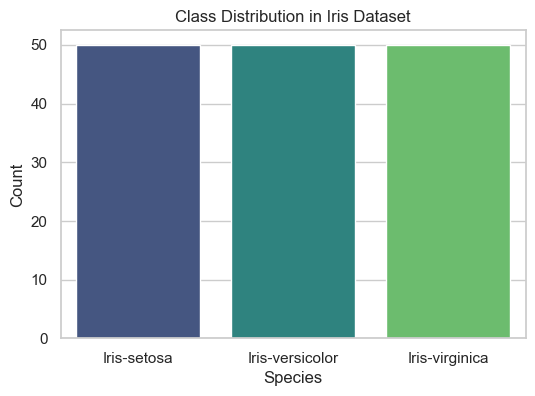

In [31]:
# Class distribution visualization
plt.figure(figsize=(6,4))
sns.countplot(x='Species', data=df, palette='viridis')
plt.title("Class Distribution in Iris Dataset")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

In [32]:
# ------------------------------------------------------------
# ✅ Step 4: Data Preprocessing — Feature Scaling
# ------------------------------------------------------------
# Drop the target column (species)
X = df.drop(columns=['Species'])

# Standardize features for equal scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n✅ Features standardized successfully!")


✅ Features standardized successfully!


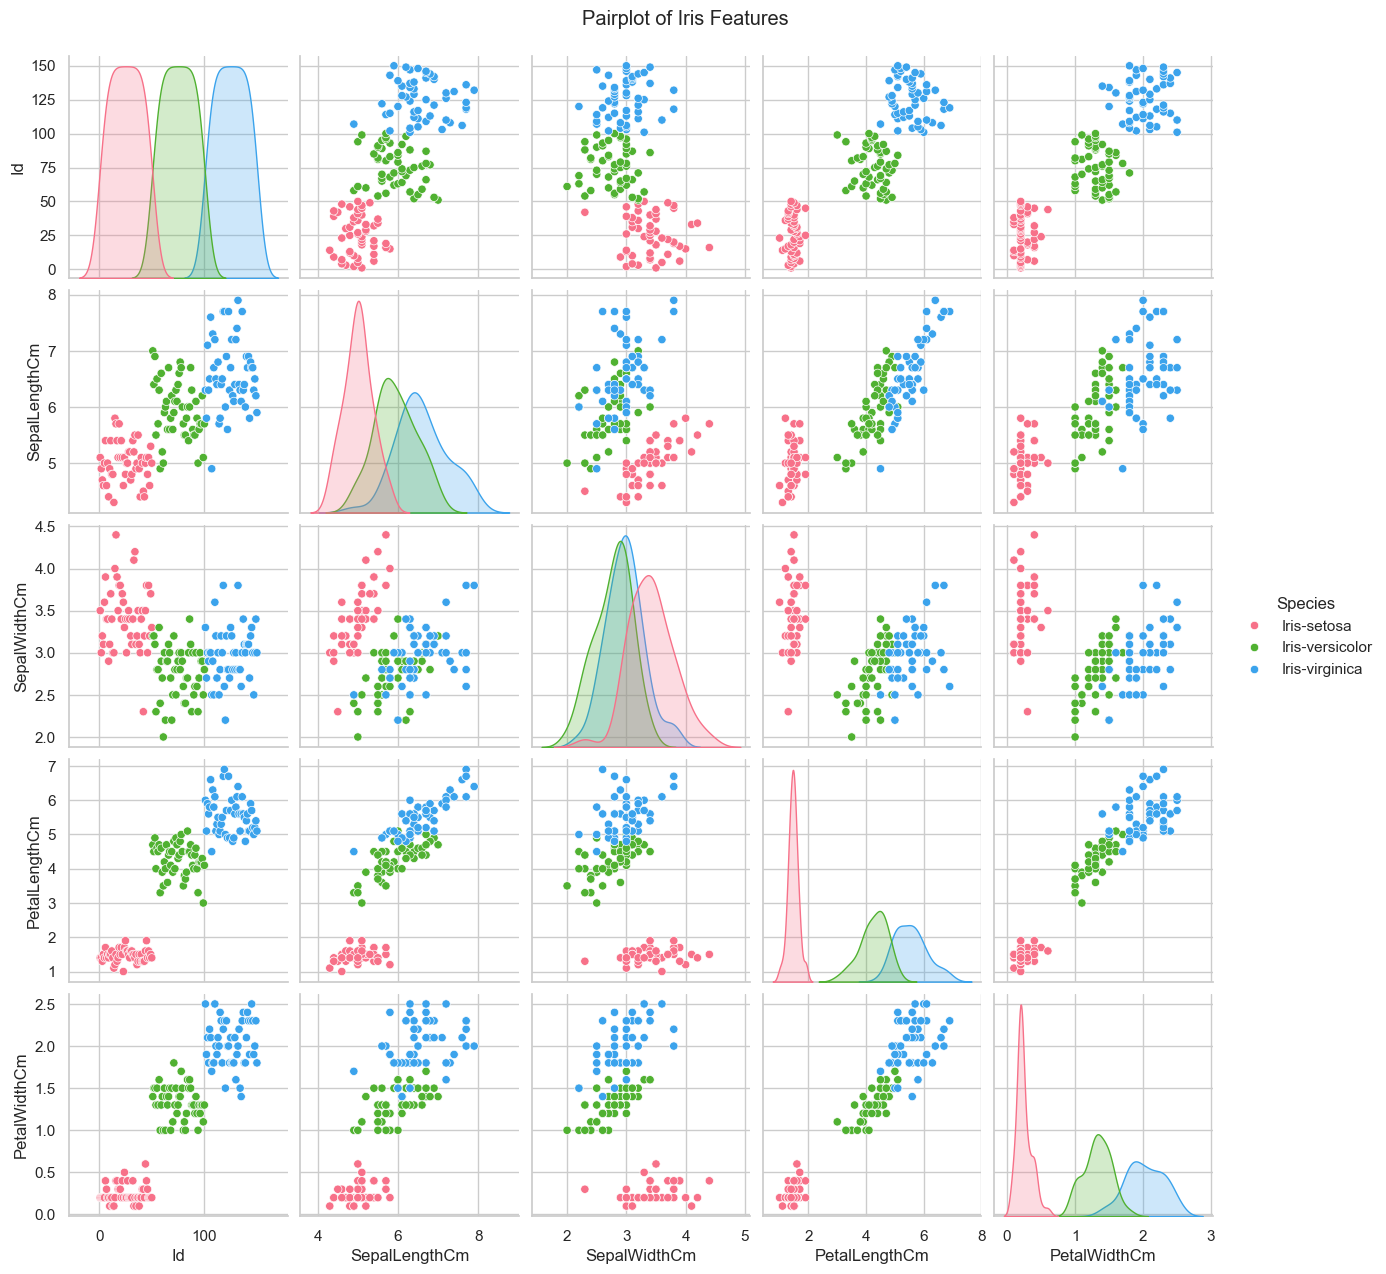

In [33]:
# ------------------------------------------------------------
# ✅ Step 5: Pairplot Visualization
# ------------------------------------------------------------
sns.pairplot(df, hue="Species", palette="husl")
plt.suptitle("Pairplot of Iris Features", y=1.02)
plt.show()

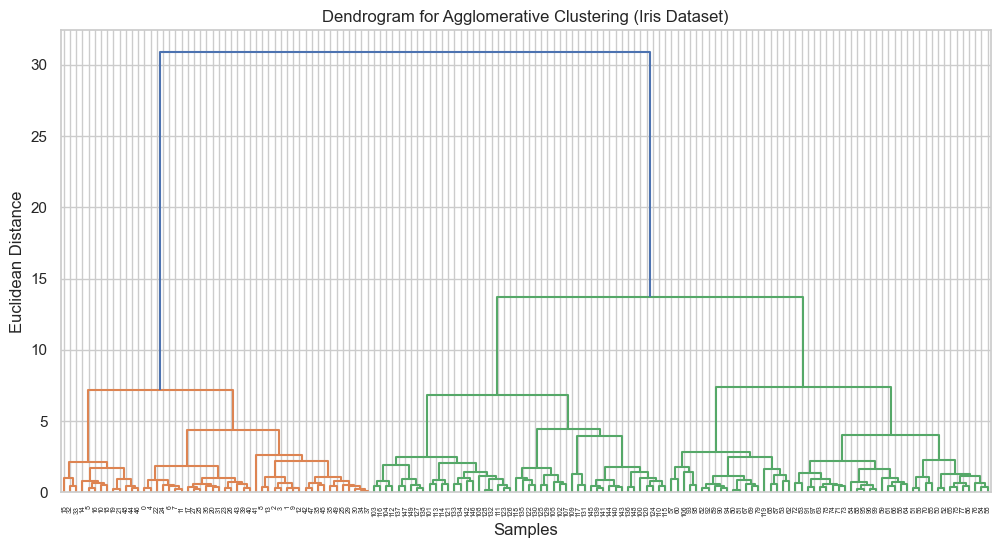

In [34]:
# ------------------------------------------------------------
# ✅ Step 6: Dendrogram Visualization
# ------------------------------------------------------------
plt.figure(figsize=(12,6))
Z = linkage(X_scaled, method='ward')  # Ward minimizes variance
dendrogram(Z)
plt.title("Dendrogram for Agglomerative Clustering (Iris Dataset)")
plt.xlabel("Samples")
plt.ylabel("Euclidean Distance")
plt.show()


In [35]:
# ------------------------------------------------------------
# ✅ Step 7: Apply Agglomerative Clustering
# ------------------------------------------------------------
# metric='euclidean' is the default, 'linkage' specifies the method
agg = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df['cluster'] = agg.fit_predict(X_scaled)

print("\n✅ Agglomerative Clustering Applied Successfully!")
print("\nCluster Counts:\n", df['cluster'].value_counts())




✅ Agglomerative Clustering Applied Successfully!

Cluster Counts:
 cluster
0    52
1    50
2    48
Name: count, dtype: int64


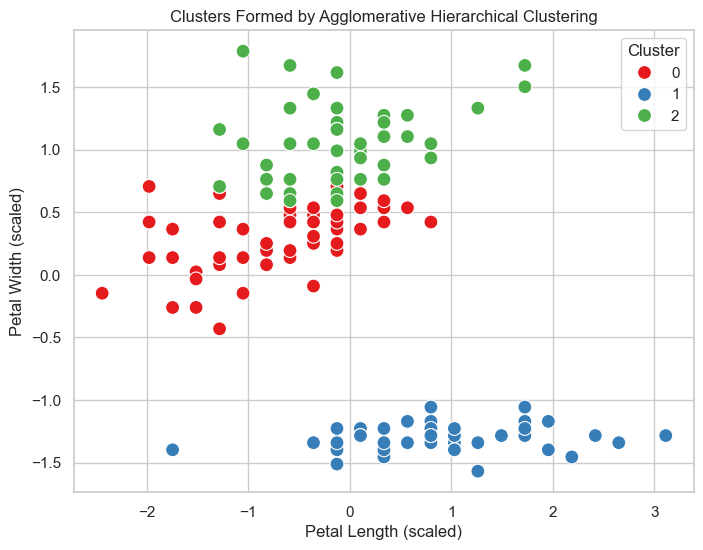

In [36]:
# ------------------------------------------------------------
# ✅ Step 8: Visualize Clusters (2D)
# ------------------------------------------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_scaled[:, 2], y=X_scaled[:, 3],
                hue=df['cluster'], palette='Set1', s=100)
plt.title("Clusters Formed by Agglomerative Hierarchical Clustering")
plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.legend(title="Cluster")
plt.show()

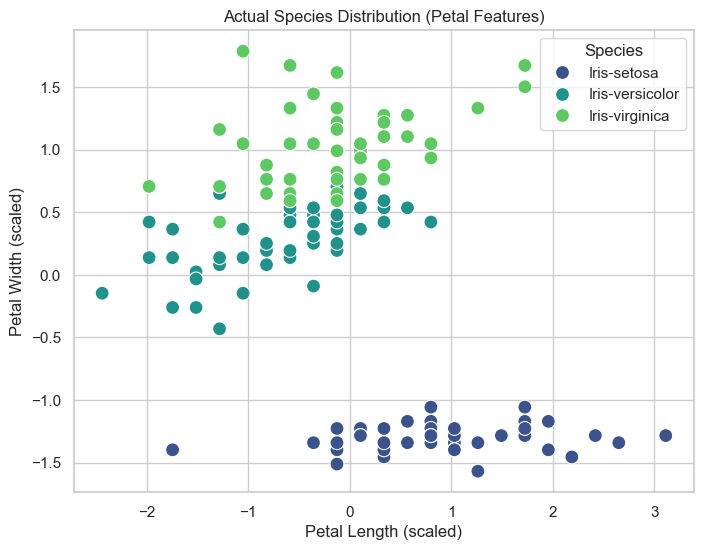

In [38]:
# ------------------------------------------------------------
# ✅ Step 9: Visualize Actual Species Distribution
# ------------------------------------------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_scaled[:, 2], y=X_scaled[:, 3],
                hue=df['Species'], palette='viridis', s=100)
plt.title("Actual Species Distribution (Petal Features)")
plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.legend(title="Species")
plt.show()


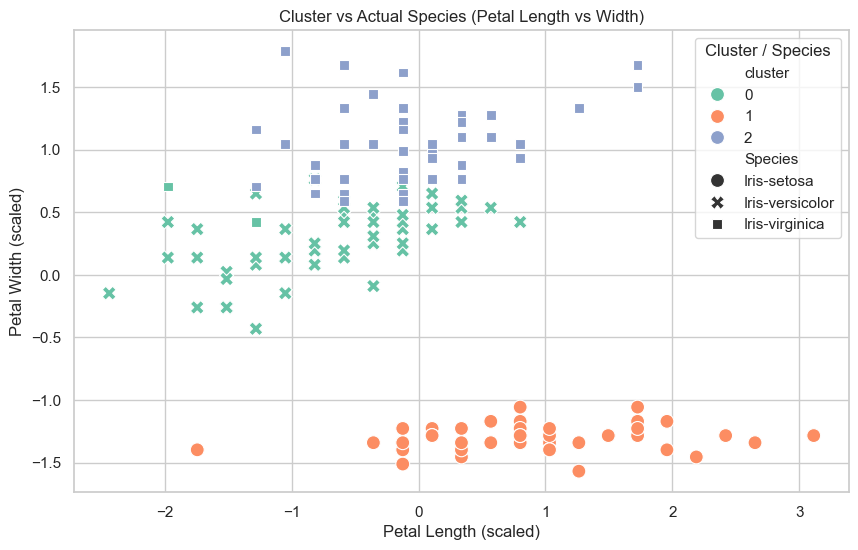

In [40]:
# ------------------------------------------------------------
# ✅ Step 10: Combined View — Cluster vs Actual Species
# ------------------------------------------------------------
plt.figure(figsize=(10,6))
sns.scatterplot(x=X_scaled[:, 2], y=X_scaled[:, 3],
                hue=df['cluster'], style=df['Species'],
                palette='Set2', s=100)
plt.title("Cluster vs Actual Species (Petal Length vs Width)")
plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.legend(title="Cluster / Species")
plt.show()


📊 Confusion Matrix (Clusters vs Actual Species):

[[ 0 50  0]
 [50  0  0]
 [ 2  0 48]]


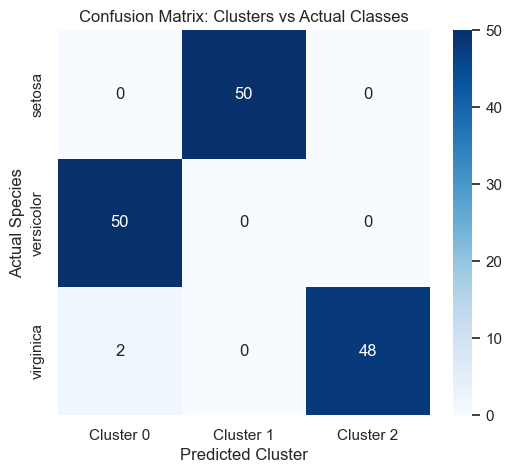

In [41]:
# ------------------------------------------------------------
# ✅ Step 11: Evaluate with Confusion Matrix
# ------------------------------------------------------------
cm = confusion_matrix(df['Species'].astype('category').cat.codes, df['cluster'])

print("\n📊 Confusion Matrix (Clusters vs Actual Species):\n")
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cluster 0','Cluster 1','Cluster 2'],
            yticklabels=['setosa','versicolor','virginica'])
plt.title("Confusion Matrix: Clusters vs Actual Classes")
plt.xlabel("Predicted Cluster")
plt.ylabel("Actual Species")
plt.show()

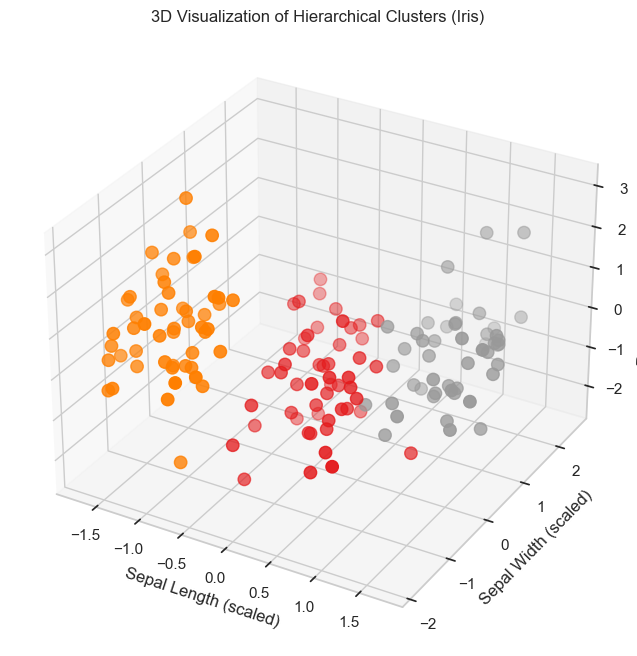

In [42]:
# ------------------------------------------------------------
# ✅ Step 12: 3D Visualization of Clusters
# ------------------------------------------------------------
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2],
           c=df['cluster'], cmap='Set1', s=80)
ax.set_title("3D Visualization of Hierarchical Clusters (Iris)")
ax.set_xlabel("Sepal Length (scaled)")
ax.set_ylabel("Sepal Width (scaled)")
ax.set_zlabel("Petal Length (scaled)")
plt.show()


In [43]:
# ------------------------------------------------------------
# ✅ Step 13: Save Clustered Data
# ------------------------------------------------------------
df.to_csv("iris_clustered_output.csv", index=False)
print("\n✅ Clustered data saved as iris_clustered_output.csv")


✅ Clustered data saved as iris_clustered_output.csv
